📚 **Importación de libreías**

In [1]:
# libreías base para el eda
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

💾 **Carga de datos**

In [2]:
# Librerías adicionales para EDA de detección de fraude
import warnings

warnings.filterwarnings("ignore")

# Para análisis estadístico
from scipy import stats
from scipy.stats import chi2_contingency, normaltest

# Configuración de visualización
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
# Definir rutas de datos
data_path = Path("../../data")
bronze_path = data_path / "Bronze"

# Verificar que la carpeta existe
if not bronze_path.exists():
    print(f"❌ No se encontró la carpeta: {bronze_path}")
    sys.exit(1)

# Cargar el dataset principal
dataset_file = bronze_path / "Dataset.csv"

if dataset_file.exists():
    print(f"📂 Cargando datos desde: {dataset_file}")
    df = pd.read_csv(dataset_file)

    # Información básica del dataset
    print(f"✅ Dataset cargado exitosamente")
    print(f"📊 Forma del dataset: {df.shape}")
    print(f"📋 Columnas: {list(df.columns)}")
    print(f"💾 Memoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    # Mostrar primeras filas
    print("\n🔍 Primeras 5 filas del dataset:")
    display(df.head())

else:
    print(f"❌ No se encontró el archivo: {dataset_file}")

📂 Cargando datos desde: ../../data/Bronze/Dataset.csv
✅ Dataset cargado exitosamente
📊 Forma del dataset: (1744667, 27)
📋 Columnas: ['CreditoID', 'PersonaID', 'DepartamentoResidencia', 'DepartamentoMayorFrecuenciaCompra', 'AlmacenMayorFrecuenciaPago', 'ValorPagosUltimosMes', 'AlmacenCredito', 'RiesgoAlmacen', 'DepartamentoCredito', 'FechaCredito', 'ValorCredito', 'CupoTotal', 'CupoDisponibleTotal', 'storeIdEventoA', 'FechaEventoA', 'EventoA', 'FechaEventoB', 'LocalizacionEventoB', 'LocalizacionComercioCredito', 'StatusComercioCredito', 'FrecuenciaCreditosSemana', 'CantidadCreditosUltimaSemana', 'ValorAtipicoCliente', 'ValorAtipicoComercio', 'TipoAlmacenCredito', 'TipoCliente', 'Atipico']
💾 Memoria utilizada: 1540.94 MB

🔍 Primeras 5 filas del dataset:


,CreditoID,PersonaID,DepartamentoResidencia,DepartamentoMayorFrecuenciaCompra,AlmacenMayorFrecuenciaPago,ValorPagosUltimosMes,AlmacenCredito,RiesgoAlmacen,DepartamentoCredito,FechaCredito,ValorCredito,CupoTotal,CupoDisponibleTotal,storeIdEventoA,FechaEventoA,EventoA,FechaEventoB,LocalizacionEventoB,LocalizacionComercioCredito,StatusComercioCredito,FrecuenciaCreditosSemana,CantidadCreditosUltimaSemana,ValorAtipicoCliente,ValorAtipicoComercio,TipoAlmacenCredito,TipoCliente,Atipico
0,VkZaU2NrMW5QVDA9,VkZaU1ZrMTNQVDA9,3,4,VkRGU1JtUjNQVDA9,86923.0,VkZkd2JrMTNQVDA9,1,4,2009-10-10T00:00:00.000Z,301300.0,3000000.0,3301300.0,NaN,NaN,NaN,NaN,NaN,"[7.06191889999999, -73.850623392738]",3.0,1.0,3,350140.0,563000.0,Fisico,Antiguo,0
1,VkZaU1JrNUZOWEZSV0dzOQ==,Vkcxd1ZrMHdNVVZoZWpBOQ==,4,4,VkRCU2FrNUZPVVZhZWpBOQ==,45347.0,VkZaRk9WQlJQVDA9,1,4,2005-09-12T00:00:00.000Z,190680.0,1000000.0,1113170.0,NaN,NaN,NaN,NaN,NaN,"[7.06191889999999, -73.850623392738]",1.0,1.0,4,579000.0,499553.0,Fisico,Antiguo,0
2,VkZkd1JtVnJOVVZoZWxVOQ==,VkZaU1JrMXJOWEZXVkVVOQ==,10,4,VkZaU1RtVlZOVkpRVkRBOQ==,10113443.0,Vkcxd1VsQlJQVDA9,1,4,2007-12-24T04:35:48.000Z,34900.0,0.0,34900.0,NaN,NaN,NaN,NaN,NaN,"[7.06191889999999, -73.850623392738]",3.0,NaN,10,NaN,NaN,Fisico,Antiguo,0
3,VkZkd1JtVnJOVlZSV0c4OQ==,VkZaU1JrMXJOWEZXVkVVOQ==,10,4,VkZaU1RtVlZOVkpRVkRBOQ==,10113443.0,VkZaU2JsQlJQVDA9,1,4,2007-12-13T04:35:48.000Z,156135.0,0.0,156135.0,NaN,NaN,NaN,NaN,NaN,"[7.06191889999999, -73.850623392738]",3.0,NaN,10,NaN,NaN,Fisico,Antiguo,0
4,VkZkd1JtVnJOVlZSVkUwOQ==,VkZaU1JrMXJOWEZXVkVVOQ==,10,4,VkZaU1RtVlZOVkpRVkRBOQ==,10113443.0,VkZaU2JsQlJQVDA9,1,4,2007-12-11T04:39:48.000Z,244440.0,0.0,244440.0,NaN,NaN,NaN,NaN,NaN,"[7.06191889999999, -73.850623392738]",3.0,NaN,10,NaN,NaN,Fisico,Antiguo,0


🔍 **Análisis inicial del dataset**

In [4]:
print(f"\n📋 TIPOS DE DATOS")
print("=" * 50)
print(df.dtypes)

print(f"\n❌ VALORES FALTANTES")
print("=" * 50)
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame(
    {
        "Columna": missing_data.index,
        "Valores_Faltantes": missing_data.values,
        "Porcentaje": missing_percent.values,
    }
).sort_values("Porcentaje", ascending=False)

display(missing_df[missing_df["Valores_Faltantes"] > 0])


📋 TIPOS DE DATOS
CreditoID                             object
PersonaID                             object
DepartamentoResidencia                 int64
DepartamentoMayorFrecuenciaCompra      int64
AlmacenMayorFrecuenciaPago            object
ValorPagosUltimosMes                 float64
AlmacenCredito                        object
RiesgoAlmacen                          int64
DepartamentoCredito                    int64
FechaCredito                          object
ValorCredito                         float64
CupoTotal                            float64
CupoDisponibleTotal                  float64
storeIdEventoA                        object
FechaEventoA                          object
EventoA                               object
FechaEventoB                          object
LocalizacionEventoB                   object
LocalizacionComercioCredito           object
StatusComercioCredito                float64
FrecuenciaCreditosSemana             float64
CantidadCreditosUltimaSemana         

,Columna,Valores_Faltantes,Porcentaje
15,EventoA,1657617,95.010509
13,storeIdEventoA,1657617,95.010509
14,FechaEventoA,1657617,95.010509
16,FechaEventoB,1628802,93.358905
17,LocalizacionEventoB,1628802,93.358905
18,LocalizacionComercioCredito,2295,0.131544
19,StatusComercioCredito,2295,0.131544
23,ValorAtipicoComercio,56,0.003210
22,ValorAtipicoCliente,51,0.002923
20,FrecuenciaCreditosSemana,18,0.001032


🔄 **Conversión de tipos de datos**

In [5]:
# INSPECCIÓN DE VALORES ÚNICOS EN COLUMNAS TIPO OBJECT
print("🔍 ANÁLISIS DE COLUMNAS TIPO OBJECT ANTES DE CONVERSIÓN")
print("=" * 80)

# Identificar columnas tipo object
object_columns = df.select_dtypes(include=["object"]).columns.tolist()

print(f"📊 Columnas tipo object encontradas: {len(object_columns)}")
print(f"Columnas: {object_columns}")
print("\n" + "=" * 80)

# Analizar cada columna tipo object
for col in object_columns:
    print(f"\n📋 COLUMNA: {col}")
    print("-" * 50)

    # Información básica
    total_values = len(df[col])
    non_null_values = df[col].notna().sum()
    null_values = df[col].isnull().sum()
    unique_values = df[col].nunique()

    print(f"Total de valores: {total_values:,}")
    print(f"Valores no nulos: {non_null_values:,}")
    print(f"Valores nulos: {null_values:,} ({null_values / total_values * 100:.1f}%)")
    print(f"Valores únicos: {unique_values:,}")

    # Mostrar valores únicos (limitado para no saturar la salida)
    unique_vals = df[col].dropna().unique()

    if unique_values <= 20:
        print(f"Todos los valores únicos:")
        for i, val in enumerate(sorted(unique_vals.astype(str))):
            print(f"  {i + 1:2d}. {val}")

    if unique_values > 20:
        print(f"Primeros 15 valores únicos (de {unique_values} totales):")
        for i, val in enumerate(sorted(unique_vals.astype(str))[:15]):
            print(f"  {i + 1:2d}. {val}")
        print(f"  ... y {unique_values - 15} valores más")

    # Análisis de frecuencias para columnas con pocos valores únicos
    if unique_values <= 10:
        print(f"\nFrecuencias:")
        freq_counts = df[col].value_counts(dropna=False)
        for val, count in freq_counts.items():
            percentage = count / total_values * 100
            print(f"  '{val}': {count:,} ({percentage:.1f}%)")

    print("\n" + "=" * 80)


🔍 ANÁLISIS DE COLUMNAS TIPO OBJECT ANTES DE CONVERSIÓN
📊 Columnas tipo object encontradas: 13
Columnas: ['CreditoID', 'PersonaID', 'AlmacenMayorFrecuenciaPago', 'AlmacenCredito', 'FechaCredito', 'storeIdEventoA', 'FechaEventoA', 'EventoA', 'FechaEventoB', 'LocalizacionEventoB', 'LocalizacionComercioCredito', 'TipoAlmacenCredito', 'TipoCliente']


📋 COLUMNA: CreditoID
--------------------------------------------------
Total de valores: 1,744,667
Valores no nulos: 1,744,667
Valores nulos: 0 (0.0%)
Valores únicos: 1,744,667
Primeros 15 valores únicos (de 1744667 totales):
   1. VkRCU1ZrNVZOVVZVVkRBOQ==
   2. VkRCU2FtVlZPVVZTVkZaUFpIb3dPUT09
   3. VkRCU2FtVnJPVVZYV0dzOQ==
   4. VkRGU1JrNVZNWEZhTTJ4UVZWUXdPUT09
   5. VkRGU1NrMUZOWEZSVkU1T1ZWUXdPUT09
   6. VkRGU1NtVnJPVlZaZWtKT1dub3dPUT09
   7. VkRGU1ZtVlZNVFpaTTJoUFZWUXdPUT09
   8. VkRGU1ZtVlZOVVZWVkVaUFpIb3dPUT09
   9. VkRGU1ZtVnJOVFpVV0dST1ZWUXdPUT09
  10. VkRGU1ZtVnJOWEZhZWtKUFdub3dPUT09
  11. VkRGU1drNUZNWEZoZWxKUFpIb3dPUT09
  12. VkRGU

In [6]:
# CONVERSIÓN ESPECÍFICA DE TIPOS DE DATOS SEGÚN CLASIFICACIÓN
print("⏸️ CÓDIGO DE CONVERSIÓN PREPARADO - REVISAR VALORES ÚNICOS PRIMERO")
print("=" * 70)

# Código de conversión
# Crear una copia para trabajar
df_converted = df.copy()

# 🆔 VARIABLES CATEGÓRICAS NOMINALES (IDs)
categorical_ids = [
    "CreditoID",
    "PersonaID",
    "AlmacenMayorFrecuenciaPago",
    "AlmacenCredito",
    "storeIdEventoA",
]

for col in categorical_ids:
    if col in df_converted.columns:
        df_converted[col] = df_converted[col].astype("string")
        print(f"   ✅ {col}: Convertido a string (ID categórico)")

# 🏷️ VARIABLES CATEGÓRICAS NOMINALES (Códigos/Regiones)
categorical_nominal = [
    "DepartamentoResidencia",
    "DepartamentoMayorFrecuenciaCompra",
    "DepartamentoCredito",
    "TipoAlmacenCredito",
]

for col in categorical_nominal:
    if col in df_converted.columns:
        df_converted[col] = df_converted[col].astype("category")
        print(f"   ✅ {col}: Convertido a category (nominal)")

# 📊 VARIABLES CATEGÓRICAS ORDINALES
categorical_ordinal = ["RiesgoAlmacen", "StatusComercioCredito", "TipoCliente"]

for col in categorical_ordinal:
    if col in df_converted.columns:
        df_converted[col] = df_converted[col].astype("category")
        print(f"   ✅ {col}: Convertido a category (ordinal)")

# 📅 VARIABLES DE FECHA
date_columns = ["FechaCredito", "FechaEventoA", "FechaEventoB"]

for col in date_columns:
    if col in df_converted.columns:
        try:
            # Intentar múltiples formatos de fecha
            df_converted[col] = pd.to_datetime(
                df_converted[col], errors="coerce", infer_datetime_format=True
            )
            print(f"   ✅ {col}: Convertido a datetime")
        except:
            print(f"   ❌ {col}: Error al convertir a datetime")

# 💰 VARIABLES NUMÉRICAS CONTINUAS
numeric_continuous = [
    "ValorPagosUltimosMes",
    "ValorCredito",
    "CupoTotal",
    "CupoDisponibleTotal",
    "ValorAtipicoCliente",
    "ValorAtipicoComercio",
]

for col in numeric_continuous:
    if col in df_converted.columns:
        try:
            df_converted[col] = pd.to_numeric(df_converted[col], errors="coerce")
            print(f"   ✅ {col}: Convertido a numeric (continua)")
        except:
            print(f"   ❌ {col}: Error al convertir a numeric")

# 🔢 VARIABLES NUMÉRICAS DISCRETAS (Conteos)
numeric_discrete = ["FrecuenciaCreditosSemana", "CantidadCreditosUltimaSemana"]

for col in numeric_discrete:
    if col in df_converted.columns:
        try:
            df_converted[col] = pd.to_numeric(
                df_converted[col], errors="coerce"
            ).astype("Int64")
            print(f"   ✅ {col}: Convertido a Int64 (discreta)")
        except:
            print(f"   ❌ {col}: Error al convertir a Int64")

# ✅ VARIABLES BINARIAS
# EventoA: 'SI' vs NaN -> 1/0
if "EventoA" in df_converted.columns:
    df_converted["EventoA"] = (df_converted["EventoA"] == "SI").astype("Int64")
    print(f"   ✅ EventoA: Convertido a binario (1=SI, 0=NaN)")

# Atipico: Variable objetivo binaria
if "Atipico" in df_converted.columns:
    df_converted["Atipico"] = df_converted["Atipico"].astype("Int64")
    print(f"   ✅ Atipico: Convertido a Int64 (target binario)")

# 🗺️ VARIABLES GEOESPACIALES
geo_columns = ["LocalizacionEventoB", "LocalizacionComercioCredito"]

for col in geo_columns:
    if col in df_converted.columns:
        print(
            f"   📍 {col}: Mantenido como string (requiere procesamiento geoespacial)"
        )

print(f"\\n📊 RESUMEN DE CONVERSIONES APLICADAS")
print("=" * 70)

# Comparar tipos antes y después
changes_made = []
for col in df.columns:
    if col in df_converted.columns:
        old_type = str(df[col].dtype)
        new_type = str(df_converted[col].dtype)
        if old_type != new_type:
            changes_made.append(
                {"Columna": col, "Tipo_Original": old_type, "Tipo_Nuevo": new_type}
            )

if changes_made:
    changes_df = pd.DataFrame(changes_made)
    display(changes_df)
else:
    print("No se realizaron cambios de tipo de datos")

# Actualizar el dataframe principal
print(f"\\n✅ Dataset actualizado con nuevos tipos de datos")

⏸️ CÓDIGO DE CONVERSIÓN PREPARADO - REVISAR VALORES ÚNICOS PRIMERO
   ✅ CreditoID: Convertido a string (ID categórico)
   ✅ PersonaID: Convertido a string (ID categórico)
   ✅ AlmacenMayorFrecuenciaPago: Convertido a string (ID categórico)
   ✅ AlmacenCredito: Convertido a string (ID categórico)
   ✅ storeIdEventoA: Convertido a string (ID categórico)
   ✅ DepartamentoResidencia: Convertido a category (nominal)
   ✅ DepartamentoMayorFrecuenciaCompra: Convertido a category (nominal)
   ✅ DepartamentoCredito: Convertido a category (nominal)
   ✅ TipoAlmacenCredito: Convertido a category (nominal)
   ✅ RiesgoAlmacen: Convertido a category (ordinal)
   ✅ StatusComercioCredito: Convertido a category (ordinal)
   ✅ TipoCliente: Convertido a category (ordinal)
   ✅ FechaCredito: Convertido a datetime
   ✅ FechaEventoA: Convertido a datetime
   ✅ FechaEventoB: Convertido a datetime
   ✅ ValorPagosUltimosMes: Convertido a numeric (continua)
   ✅ ValorCredito: Convertido a numeric (continua)
   

,Columna,Tipo_Original,Tipo_Nuevo
0,CreditoID,object,string
1,PersonaID,object,string
2,DepartamentoResidencia,int64,category
3,DepartamentoMayorFrecuenciaCompra,int64,category
4,AlmacenMayorFrecuenciaPago,object,string
5,AlmacenCredito,object,string
6,RiesgoAlmacen,int64,category
7,DepartamentoCredito,int64,category
8,FechaCredito,object,"datetime64[ns, UTC]"
9,storeIdEventoA,object,string


\n✅ Dataset actualizado con nuevos tipos de datos


In [7]:
display(df_converted.info())
print(f"\n📈 ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 50)
display(df_converted.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1744667 entries, 0 to 1744666
Data columns (total 27 columns):
 #   Column                             Dtype              
---  ------                             -----              
 0   CreditoID                          string             
 1   PersonaID                          string             
 2   DepartamentoResidencia             category           
 3   DepartamentoMayorFrecuenciaCompra  category           
 4   AlmacenMayorFrecuenciaPago         string             
 5   ValorPagosUltimosMes               float64            
 6   AlmacenCredito                     string             
 7   RiesgoAlmacen                      category           
 8   DepartamentoCredito                category           
 9   FechaCredito                       datetime64[ns, UTC]
 10  ValorCredito                       float64            
 11  CupoTotal                          float64            
 12  CupoDisponibleTotal                float64

None


📈 ESTADÍSTICAS DESCRIPTIVAS


,ValorPagosUltimosMes,ValorCredito,CupoTotal,CupoDisponibleTotal,EventoA,FrecuenciaCreditosSemana,CantidadCreditosUltimaSemana,ValorAtipicoCliente,ValorAtipicoComercio,Atipico
count,1.744667e+06,1.744667e+06,1.744667e+06,1.744667e+06,1744667.0,1744649.0,1744667.0,1.744616e+06,1.744611e+06,1744667.0
mean,5.312476e+05,2.476059e+05,1.774399e+06,1.408451e+06,0.049895,1.098418,3.062771,7.624383e+05,8.417151e+05,0.000231
std,5.394615e+05,2.766843e+05,1.072251e+06,1.090269e+06,0.217728,0.340497,2.345071,6.465880e+05,7.080478e+05,0.015197
min,1.940000e+02,1.000000e+04,0.000000e+00,-4.278013e+06,0.0,1.0,1.0,1.000000e+04,1.000000e+04,0.0
25%,1.845565e+05,1.000000e+05,1.000000e+06,4.873675e+05,0.0,1.0,1.0,4.100000e+05,4.993010e+05,0.0
50%,3.653780e+05,1.677210e+05,2.000000e+06,1.068454e+06,0.0,1.0,2.0,5.929000e+05,6.350000e+05,0.0
75%,6.906280e+05,2.825000e+05,3.000000e+06,2.188462e+06,0.0,1.0,4.0,8.963000e+05,8.587000e+05,0.0
max,1.737457e+07,5.542982e+06,3.000000e+06,9.858684e+06,1.0,14.0,43.0,1.400000e+07,1.902140e+07,1.0


In [8]:
# CONTAR Y ELIMINAR DUPLICADOS POR CreditoID
print("🔍 DUPLICADOS EN CreditoID")
print("=" * 40)

# Conteo
total_registros = len(df_converted)
creditos_unicos = df_converted["CreditoID"].nunique()
duplicados = total_registros - creditos_unicos

print(f"Total registros: {total_registros:,}")
print(f"CreditoIDs únicos: {creditos_unicos:,}")
print(f"Duplicados: {duplicados:,}")

if duplicados > 0:
    # Eliminar duplicados
    df_converted = df_converted.drop_duplicates(subset=["CreditoID"], keep="first")
    print(f"✅ {duplicados:,} duplicados eliminados")
    print(f"Registros finales: {len(df_converted):,}")
else:
    print("✅ No hay duplicados")

🔍 DUPLICADOS EN CreditoID
Total registros: 1,744,667
CreditoIDs únicos: 1,744,667
Duplicados: 0
✅ No hay duplicados


🔧 **Creación de variables derivadas**

A continuación se describen las variables calculadas a partir de la información original del dataset. Estas fueron creadas con el objetivo de enriquecer el modelo de detección de transacciones atípicas, incorporando dimensiones temporales, financieras y de comportamiento del cliente.

| Variable                             | Descripción                                                                                         |
|--------------------------------------|-----------------------------------------------------------------------------------------------------|
| `porcentaje_cupo_expandido_utilizado` | Porcentaje de uso potencial del cupo, calculado como: (Valor del crédito + cupo disponible) / cupo total. Ayuda a identificar clientes cerca del límite financiero. |
| `dia_credito`                        | Día del mes en que se otorgó el crédito (de 1 a 31). Permite capturar patrones cíclicos o comportamientos anómalos en fechas específicas. |
| `hora_credito`                       | Hora del día en que se registró el crédito (0 a 23). Permite detectar transacciones fuera del horario habitual. |
| `mes_credito`                        | Mes en que se realizó el crédito. Útil para análisis estacionales o comportamiento por campaña. |
| `es_fin_de_semana`                  | Valor booleano que indica si el crédito se realizó en sábado o domingo. Puede reflejar operaciones fuera del horario típico. |
| `es_dia_pago`                        | Valor booleano que indica si el día del crédito fue 15, 28, 29 o 30, fechas comunes de pagos de nómina. |
| `es_noche_o_madrugada`              | Valor booleano que indica si la hora fue menor a 6 o mayor o igual a 22. Detecta transacciones en horarios atípicos. |
| `frecuencia_categoria_alta`         | Valor booleano que indica si la frecuencia de créditos semanales del cliente es mayor a 2. Detecta clientes con actividad elevada. |
| `es_dia_laboral`                    | Valor booleano que indica si el crédito se realizó entre lunes y viernes. Contrasta operaciones regulares vs. especiales. |
| `departamento_match_residencia_credito` | Valor booleano que indica si el departamento de residencia del cliente coincide con el departamento donde se emitió el crédito. Identifica operaciones en territorios distintos al habitual. |



In [9]:
# CREACIÓN DE VARIABLES DERIVADAS
print("🔧 GENERANDO VARIABLES DERIVADAS")
print("=" * 50)

# Crear copia del DataFrame actual
df_new_variables = df_converted.copy()

try:
    # 1. Porcentaje de cupo expandido utilizado
    df_new_variables["porcentaje_cupo_expandido_utilizado"] = (
        (df_new_variables["ValorCredito"] + df_new_variables["CupoDisponibleTotal"])
        / df_new_variables["CupoTotal"]
    ).round(4)
    print("✅ porcentaje_cupo_expandido_utilizado")

    # 2-4. Variables temporales individuales
    df_new_variables["dia_credito"] = df_new_variables["FechaCredito"].dt.day
    df_new_variables["mes_credito"] = df_new_variables["FechaCredito"].dt.month
    df_new_variables["hora_credito"] = df_new_variables["FechaCredito"].dt.hour
    df_new_variables["dia_semana"] = df_new_variables[
        "FechaCredito"
    ].dt.weekday  # 0=Lunes, 6=Domingo
    print("✅ dia_credito, mes_credito, hora_credito, dia_semana")

    # 5. Es día de pago - BINARIA (15 o 30 cualquier mes, o 28/29 solo si es febrero)
    df_new_variables["es_dia_pago"] = (
        (df_new_variables["dia_credito"].isin([15, 30]))
        | (
            df_new_variables["dia_credito"].isin([28, 29])
            & (df_new_variables["mes_credito"] == 2)
        )
    ).astype(int)

    print("✅ es_dia_pago (1 si día 15 o 30, o si 28/29 en febrero; 0 en otros casos)")

    # 6. Es noche o madrugada - BINARIA
    df_new_variables["es_noche_o_madrugada"] = (
        (df_new_variables["hora_credito"] < 6)
        | (df_new_variables["hora_credito"] >= 22)
    ).astype(int)
    print("✅ es_noche_o_madrugada (binaria: 1=<6h o >=22h, 0=día)")

    # 7. Es temporada alta - BINARIA
    df_new_variables["es_temporada_alta"] = (
        df_new_variables["mes_credito"].isin([11, 12, 1])
    ).astype(int)
    print("✅ es_temporada_alta (binaria: 1=Nov/Dic/Ene, 0=otros)")

    # 8. Es fin de semana - BINARIA
    df_new_variables["es_fin_de_semana"] = (df_new_variables["dia_semana"] >= 5).astype(
        int
    )
    print("✅ es_fin_de_semana (binaria: 1=sáb/dom, 0=lun-vie)")

    # 9. Frecuencia alta de créditos - BINARIA
    df_new_variables["frecuencia_categoria_alta"] = (
        df_new_variables["FrecuenciaCreditosSemana"] > 3
    ).astype("Int64")
    print("✅ frecuencia_categoria_alta (binaria: 1=>3 créditos/sem, 0=<=3)")

    # 10. Match departamento - BINARIA
    df_new_variables["departamento_match_residencia_credito"] = (
        df_new_variables["DepartamentoResidencia"]
        == df_new_variables["DepartamentoCredito"]
    ).astype(int)
    print("✅ departamento_match_residencia_credito (binaria: 1=match, 0=diferente)")

    # 11. Cupo alto utilizado - BINARIA
    df_new_variables["cupo_alto_utilizado"] = (
        (df_new_variables["ValorCredito"] / df_new_variables["CupoTotal"]) > 0.8
    ).astype(int)
    print("✅ cupo_alto_utilizado (binaria: 1=>80% cupo, 0=<=80%)")

    print(f"\n📊 RESUMEN DE VARIABLES DERIVADAS")
    print("=" * 50)

    # Lista de variables nuevas
    variables_temporales = ["dia_credito", "mes_credito", "hora_credito", "dia_semana"]
    variables_binarias = [
        "es_dia_pago",
        "es_noche_o_madrugada",
        "es_temporada_alta",
        "es_fin_de_semana",
        "frecuencia_categoria_alta",
        "departamento_match_residencia_credito",
        "cupo_alto_utilizado",
    ]
    variables_continuas = ["porcentaje_cupo_expandido_utilizado"]

    todas_nuevas_variables = (
        variables_temporales + variables_binarias + variables_continuas
    )

    print(f"Variables originales: {df_converted.shape[1]}")
    print(f"Variables temporales nuevas: {len(variables_temporales)}")
    print(f"Variables binarias nuevas: {len(variables_binarias)}")
    print(f"Variables continuas nuevas: {len(variables_continuas)}")
    print(f"Total variables nuevas: {len(todas_nuevas_variables)}")
    print(f"Total variables final: {df_new_variables.shape[1]}")
    print(f"Registros: {df_new_variables.shape[0]:,}")

    # Mostrar estadísticas de las nuevas variables
    print(f"\n📈 ESTADÍSTICAS DE VARIABLES DERIVADAS")
    print("=" * 50)
    display(df_new_variables[todas_nuevas_variables].describe())

except Exception as e:
    print(f"❌ Error al crear variables derivadas: {e}")
    raise

🔧 GENERANDO VARIABLES DERIVADAS
✅ porcentaje_cupo_expandido_utilizado
✅ dia_credito, mes_credito, hora_credito, dia_semana
✅ es_dia_pago (1 si día 15 o 30, o si 28/29 en febrero; 0 en otros casos)
✅ es_noche_o_madrugada (binaria: 1=<6h o >=22h, 0=día)
✅ es_temporada_alta (binaria: 1=Nov/Dic/Ene, 0=otros)
✅ es_fin_de_semana (binaria: 1=sáb/dom, 0=lun-vie)
✅ frecuencia_categoria_alta (binaria: 1=>3 créditos/sem, 0=<=3)
✅ departamento_match_residencia_credito (binaria: 1=match, 0=diferente)
✅ cupo_alto_utilizado (binaria: 1=>80% cupo, 0=<=80%)

📊 RESUMEN DE VARIABLES DERIVADAS
Variables originales: 27
Variables temporales nuevas: 4
Variables binarias nuevas: 7
Variables continuas nuevas: 1
Total variables nuevas: 12
Total variables final: 39
Registros: 1,744,667

📈 ESTADÍSTICAS DE VARIABLES DERIVADAS


,dia_credito,mes_credito,hora_credito,dia_semana,es_dia_pago,es_noche_o_madrugada,es_temporada_alta,es_fin_de_semana,frecuencia_categoria_alta,departamento_match_residencia_credito,cupo_alto_utilizado,porcentaje_cupo_expandido_utilizado
count,1.744667e+06,1.744667e+06,1.744667e+06,1.744667e+06,1.744667e+06,1.744667e+06,1.744667e+06,1.744667e+06,1744649.0,1.744667e+06,1.744667e+06,1.744665e+06
mean,1.569112e+01,7.077882e+00,1.477083e+01,3.243026e+00,5.769238e-02,5.834351e-03,1.593427e-04,3.427852e-01,0.001305,8.029343e-01,4.473690e-02,NaN
std,8.914496e+00,7.054502e-01,3.156951e+00,1.940174e+00,2.331609e-01,7.615980e-02,1.262210e-02,4.746405e-01,0.036103,3.977825e-01,2.067258e-01,NaN
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,-inf
25%,8.000000e+00,7.000000e+00,1.200000e+01,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1.000000e+00,0.000000e+00,7.396000e-01
50%,1.600000e+01,7.000000e+00,1.500000e+01,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1.000000e+00,0.000000e+00,9.774000e-01
75%,2.300000e+01,8.000000e+00,1.700000e+01,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.0,1.000000e+00,0.000000e+00,1.199400e+00
max,3.100000e+01,1.200000e+01,2.300000e+01,6.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.0,1.000000e+00,1.000000e+00,inf


In [10]:
# Evento B - BINARIA: 1 si hay fecha registrada, 0 si está vacía
df_new_variables["evento_b"] = df_new_variables["FechaEventoB"].notna().astype(int)

print("✅ evento_b (binaria: 1 si FechaEventoB tiene valor, 0 si NaN)")

df_new_variables["evento_b"] = df_new_variables["evento_b"].astype("category")

print("✅ evento_b convertido a tipo category")

✅ evento_b (binaria: 1 si FechaEventoB tiene valor, 0 si NaN)
✅ evento_b convertido a tipo category


In [11]:
# ELIMINAR VARIABLES DE COORDENADAS
print("🗑️ ELIMINANDO VARIABLES DE COORDENADAS")
print("=" * 40)

# Variables a eliminar
coordenadas_cols = ["LocalizacionEventoB", "LocalizacionComercioCredito"]

# Verificar cuáles existen
cols_a_eliminar = [col for col in coordenadas_cols if col in df_new_variables.columns]

if cols_a_eliminar:
    df_new_variables = df_new_variables.drop(columns=cols_a_eliminar)
    print(f"✅ Eliminadas {len(cols_a_eliminar)} variables: {cols_a_eliminar}")
    print(f"📊 Shape final: {df_new_variables.shape}")
else:
    print("ℹ️ No se encontraron variables de coordenadas para eliminar")

print(f"\n💡 RAZÓN: Las coordenadas geográficas requieren procesamiento especial")
print("   - Formato texto no apto para análisis estadístico directo")
print("   - Necesitan transformación a distancias, zonas o clustering")
print("   - Alta cardinalidad genera ruido en EDA básico")

🗑️ ELIMINANDO VARIABLES DE COORDENADAS
✅ Eliminadas 2 variables: ['LocalizacionEventoB', 'LocalizacionComercioCredito']
📊 Shape final: (1744667, 38)

💡 RAZÓN: Las coordenadas geográficas requieren procesamiento especial
   - Formato texto no apto para análisis estadístico directo
   - Necesitan transformación a distancias, zonas o clustering
   - Alta cardinalidad genera ruido en EDA básico


In [12]:
# CONVERTIR VARIABLES BINARIAS A CATEGORY
print("🔄 CONVIRTIENDO VARIABLES BINARIAS (0/1) A CATEGORY")
print("=" * 50)

# Variables binarias (solo valores 0 y 1)
binary_vars = [
    "EventoA",
    "Atipico",
    "es_dia_pago",
    "es_noche_o_madrugada",
    "es_temporada_alta",
    "es_fin_de_semana",
    "frecuencia_categoria_alta",
    "departamento_match_residencia_credito",
    "cupo_alto_utilizado",
]

# Convertir solo las que existen en el dataframe
for var in binary_vars:
    if var in df_new_variables.columns:
        # Verificar que solo tenga valores 0, 1 y posibles NaN
        unique_vals = df_new_variables[var].dropna().unique()
        if set(unique_vals).issubset({0, 1}):
            df_new_variables[var] = df_new_variables[var].astype("category")
            print(f"✅ {var}: Convertido a category")
        else:
            print(f"⚠️ {var}: No convertido (valores: {sorted(unique_vals)})")

print(f"\n📊 Conversión completada")
print(f"Shape del dataframe: {df_new_variables.shape}")

🔄 CONVIRTIENDO VARIABLES BINARIAS (0/1) A CATEGORY
✅ EventoA: Convertido a category
✅ Atipico: Convertido a category
✅ es_dia_pago: Convertido a category
✅ es_noche_o_madrugada: Convertido a category
✅ es_temporada_alta: Convertido a category
✅ es_fin_de_semana: Convertido a category
✅ frecuencia_categoria_alta: Convertido a category
✅ departamento_match_residencia_credito: Convertido a category
✅ cupo_alto_utilizado: Convertido a category

📊 Conversión completada
Shape del dataframe: (1744667, 38)


📈 **Análisis univariable**

Variables numericas

In [13]:
numerical_cols = df_new_variables.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols

['ValorPagosUltimosMes',
 'ValorCredito',
 'CupoTotal',
 'CupoDisponibleTotal',
 'FrecuenciaCreditosSemana',
 'CantidadCreditosUltimaSemana',
 'ValorAtipicoCliente',
 'ValorAtipicoComercio',
 'porcentaje_cupo_expandido_utilizado',
 'dia_credito',
 'mes_credito',
 'hora_credito',
 'dia_semana']

In [14]:
df_new_variables.describe()

,ValorPagosUltimosMes,ValorCredito,CupoTotal,CupoDisponibleTotal,FrecuenciaCreditosSemana,CantidadCreditosUltimaSemana,ValorAtipicoCliente,ValorAtipicoComercio,porcentaje_cupo_expandido_utilizado,dia_credito,mes_credito,hora_credito,dia_semana
count,1.744667e+06,1.744667e+06,1.744667e+06,1.744667e+06,1744649.0,1744667.0,1.744616e+06,1.744611e+06,1.744665e+06,1.744667e+06,1.744667e+06,1.744667e+06,1.744667e+06
mean,5.312476e+05,2.476059e+05,1.774399e+06,1.408451e+06,1.098418,3.062771,7.624383e+05,8.417151e+05,NaN,1.569112e+01,7.077882e+00,1.477083e+01,3.243026e+00
std,5.394615e+05,2.766843e+05,1.072251e+06,1.090269e+06,0.340497,2.345071,6.465880e+05,7.080478e+05,NaN,8.914496e+00,7.054502e-01,3.156951e+00,1.940174e+00
min,1.940000e+02,1.000000e+04,0.000000e+00,-4.278013e+06,1.0,1.0,1.000000e+04,1.000000e+04,-inf,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,1.845565e+05,1.000000e+05,1.000000e+06,4.873675e+05,1.0,1.0,4.100000e+05,4.993010e+05,7.396000e-01,8.000000e+00,7.000000e+00,1.200000e+01,2.000000e+00
50%,3.653780e+05,1.677210e+05,2.000000e+06,1.068454e+06,1.0,2.0,5.929000e+05,6.350000e+05,9.774000e-01,1.600000e+01,7.000000e+00,1.500000e+01,3.000000e+00
75%,6.906280e+05,2.825000e+05,3.000000e+06,2.188462e+06,1.0,4.0,8.963000e+05,8.587000e+05,1.199400e+00,2.300000e+01,8.000000e+00,1.700000e+01,5.000000e+00
max,1.737457e+07,5.542982e+06,3.000000e+06,9.858684e+06,14.0,43.0,1.400000e+07,1.902140e+07,inf,3.100000e+01,1.200000e+01,2.300000e+01,6.000000e+00


Desde este momento podemos observar algunas inconsistencias dentro de la variable cupo, no debería haber cupo disponible negativo

📊 Variables numéricas encontradas: 13
Variables: ['ValorPagosUltimosMes', 'ValorCredito', 'CupoTotal', 'CupoDisponibleTotal', 'FrecuenciaCreditosSemana', 'CantidadCreditosUltimaSemana', 'ValorAtipicoCliente', 'ValorAtipicoComercio', 'porcentaje_cupo_expandido_utilizado', 'dia_credito', 'mes_credito', 'hora_credito', 'dia_semana']


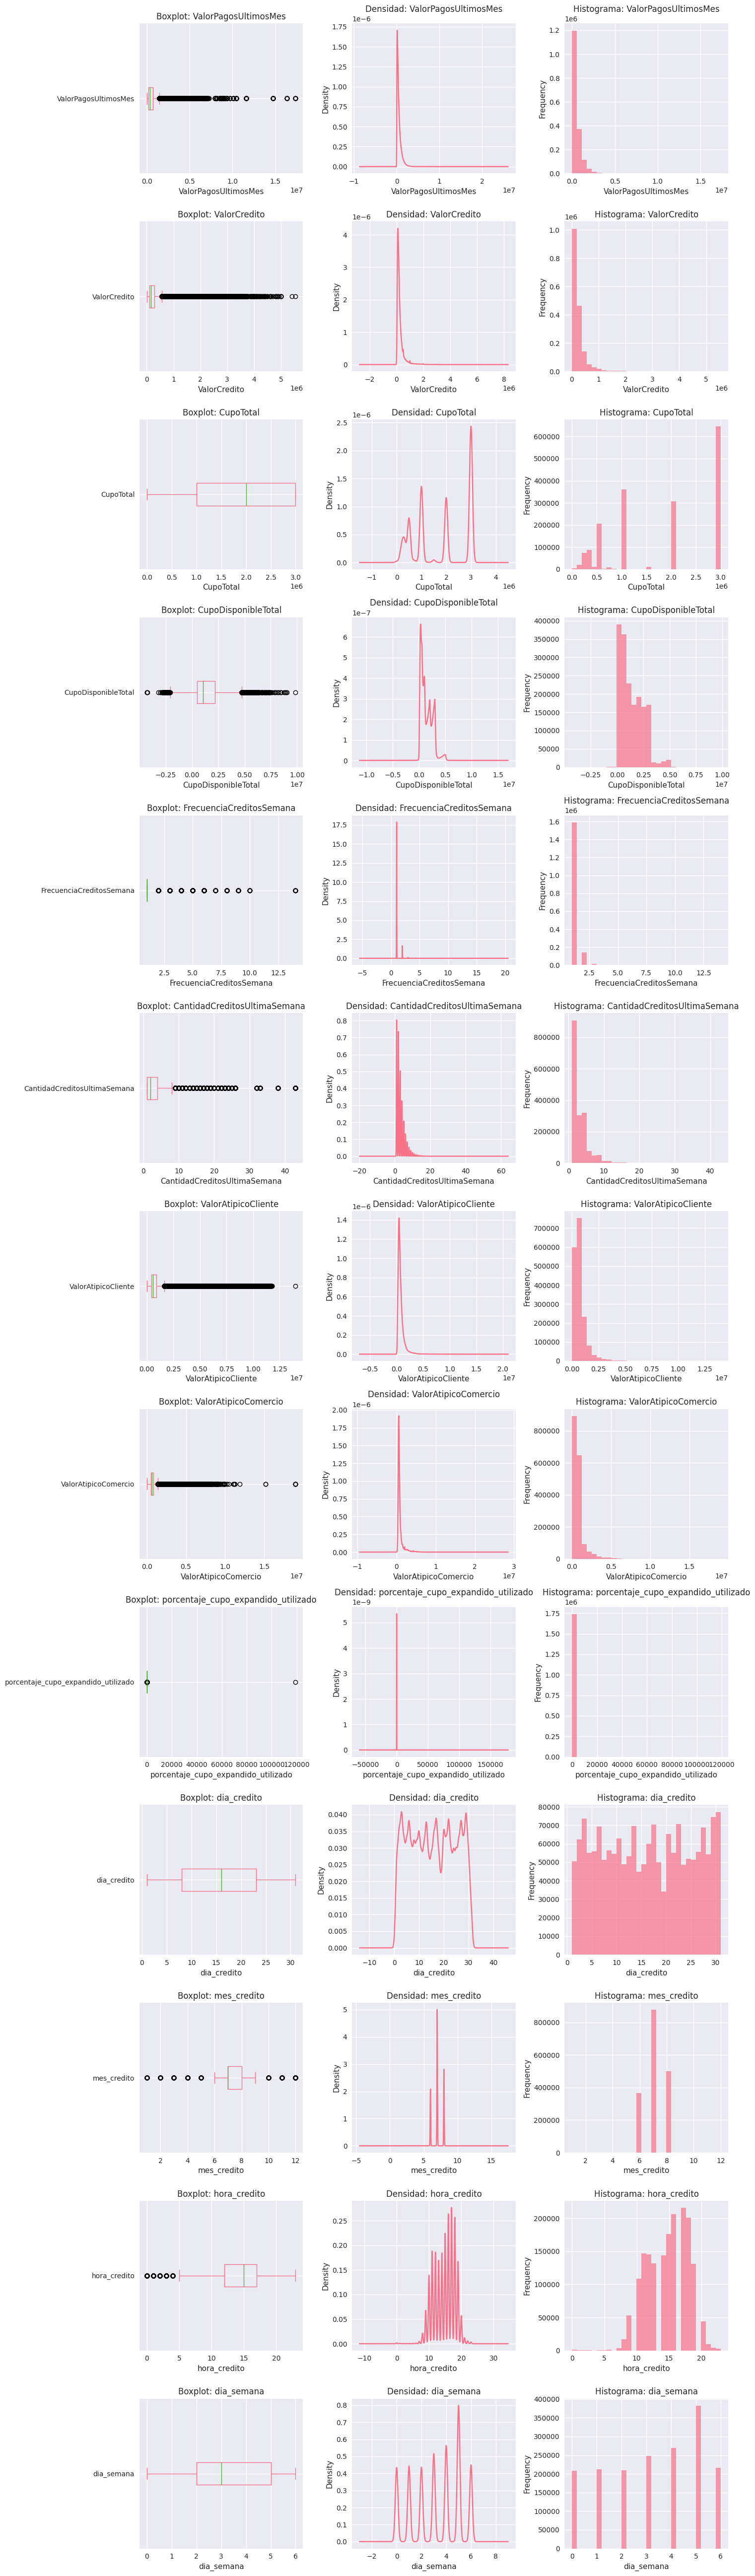


🔍 REPORTE DE VALORES PROBLEMÁTICOS
FrecuenciaCreditosSemana: 0 inf, 18 NaN
ValorAtipicoCliente: 0 inf, 51 NaN
ValorAtipicoComercio: 0 inf, 56 NaN
porcentaje_cupo_expandido_utilizado: 5158 inf, 2 NaN


In [15]:
# VISUALIZACIÓN DE VARIABLES NUMÉRICAS
num_cols = df_new_variables.select_dtypes(include=[np.number]).columns.tolist()

print(f"📊 Variables numéricas encontradas: {len(num_cols)}")
print(f"Variables: {num_cols}")

if num_cols:
    # Crear subplots dinámicamente
    n_cols = len(num_cols)
    fig, axes = plt.subplots(nrows=n_cols, ncols=3, figsize=(15, 4 * n_cols))

    # Manejar caso de una sola variable
    if n_cols == 1:
        axes = axes.reshape(1, -1)

    for i, col in enumerate(num_cols):
        # Limpiar datos: eliminar NaN, inf, -inf
        clean_data = df_new_variables[col].replace([np.inf, -np.inf], np.nan).dropna()

        if len(clean_data) == 0:
            # Si no hay datos válidos, mostrar mensaje
            for j in range(3):
                axes[i, j].text(
                    0.5,
                    0.5,
                    f"Sin datos válidos\npara {col}",
                    ha="center",
                    va="center",
                    transform=axes[i, j].transAxes,
                )
                axes[i, j].set_title(f"Sin datos: {col}")
            continue

        # Boxplot
        clean_data.plot(kind="box", ax=axes[i, 0], vert=False)
        axes[i, 0].set_title(f"Boxplot: {col}")
        axes[i, 0].set_xlabel(col)

        # Density plot - solo si hay variabilidad en los datos
        if clean_data.nunique() > 1:
            clean_data.plot(kind="density", ax=axes[i, 1])
            axes[i, 1].set_title(f"Densidad: {col}")
            axes[i, 1].set_xlabel(col)
        else:
            axes[i, 1].text(
                0.5,
                0.5,
                f"Sin variabilidad\nen {col}",
                ha="center",
                va="center",
                transform=axes[i, 1].transAxes,
            )
            axes[i, 1].set_title(f"Densidad: {col}")

        # Histogram
        clean_data.plot(kind="hist", bins=30, ax=axes[i, 2], alpha=0.7)
        axes[i, 2].set_title(f"Histograma: {col}")
        axes[i, 2].set_xlabel(col)

    plt.tight_layout()
    plt.show()

    # Reporte de valores problemáticos
    print(f"\n🔍 REPORTE DE VALORES PROBLEMÁTICOS")
    print("=" * 50)
    for col in num_cols:
        inf_count = np.isinf(df_new_variables[col]).sum()
        nan_count = df_new_variables[col].isnull().sum()
        if inf_count > 0 or nan_count > 0:
            print(f"{col}: {inf_count} inf, {nan_count} NaN")
else:
    print("❌ No se encontraron variables numéricas para visualizar")


Variables categoricas

In [16]:
# descripción de columnas categoricas
df_new_variables.describe(include="category")

,DepartamentoResidencia,DepartamentoMayorFrecuenciaCompra,RiesgoAlmacen,DepartamentoCredito,EventoA,StatusComercioCredito,TipoAlmacenCredito,TipoCliente,Atipico,es_dia_pago,es_noche_o_madrugada,es_temporada_alta,es_fin_de_semana,frecuencia_categoria_alta,departamento_match_residencia_credito,cupo_alto_utilizado,evento_b
count,1744667,1744667,1744667,1744667,1744667,1742372.0,1744667,1744667,1744667,1744667,1744667,1744667,1744667,1744649,1744667,1744667,1744667
unique,34,34,3,34,2,4.0,2,2,2,2,2,2,2,2,2,2,2
top,4,4,1,4,0,1.0,Fisico,Antiguo,0,0,0,0,0,0,1,0,0
freq,276344,246812,1726668,268858,1657617,1720082.0,1611825,1701513,1744264,1644013,1734488,1744389,1146621,1742372,1400853,1666616,1628802


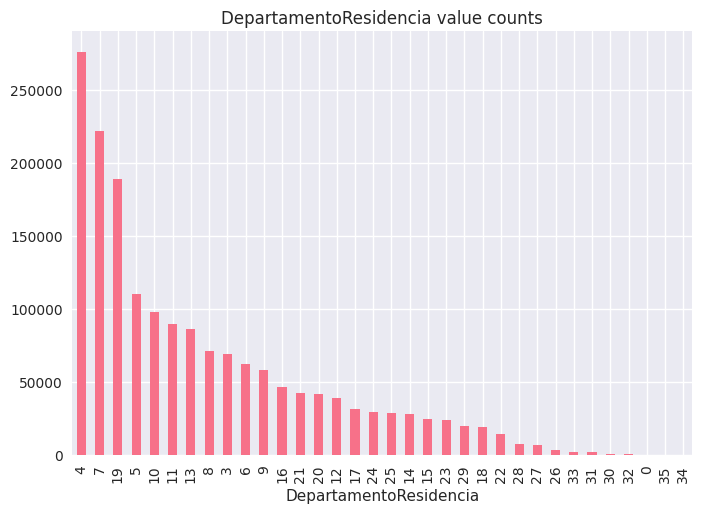

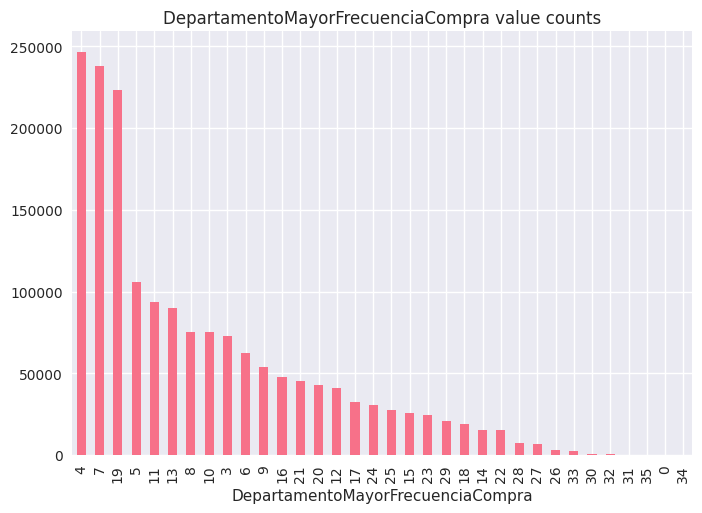

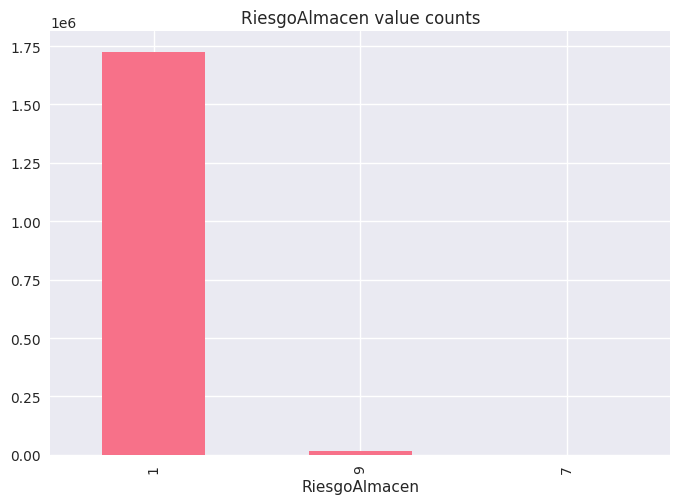

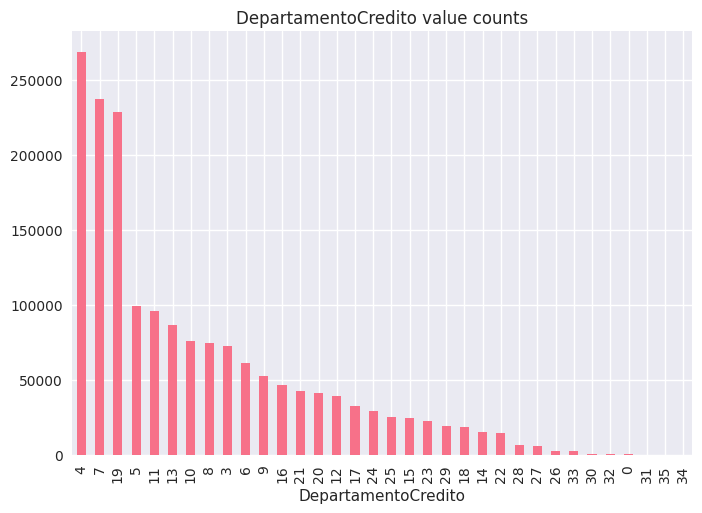

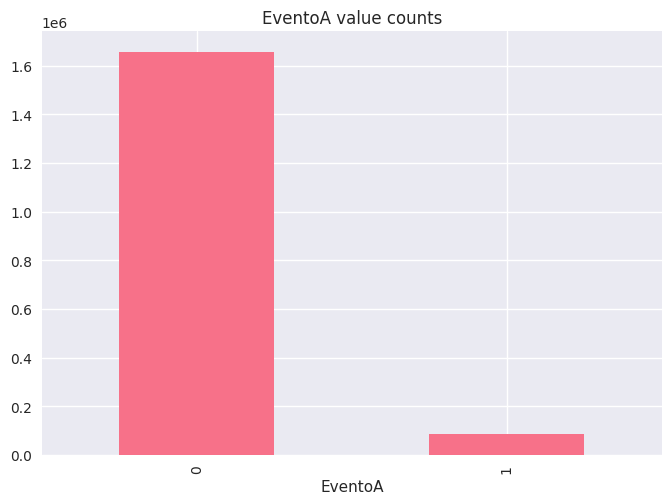

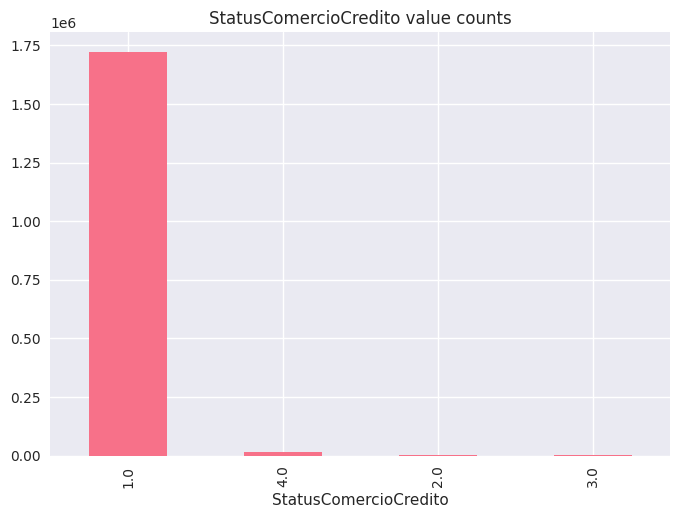

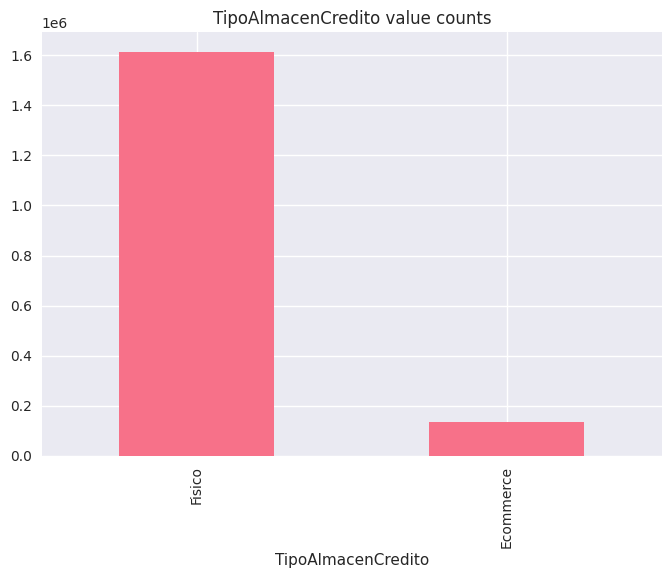

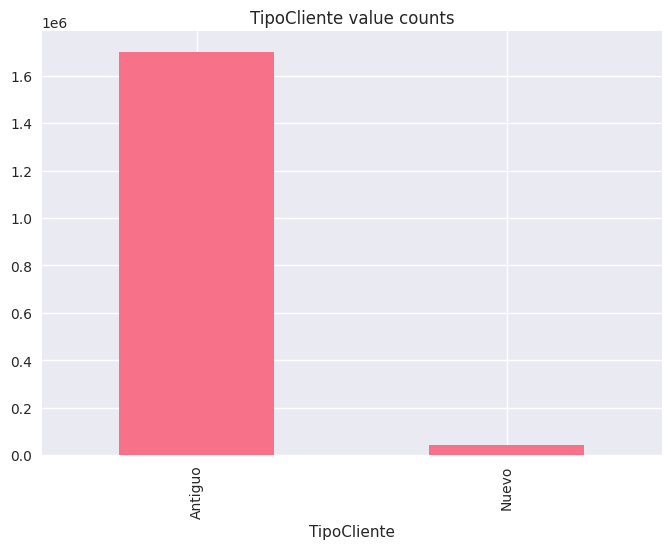

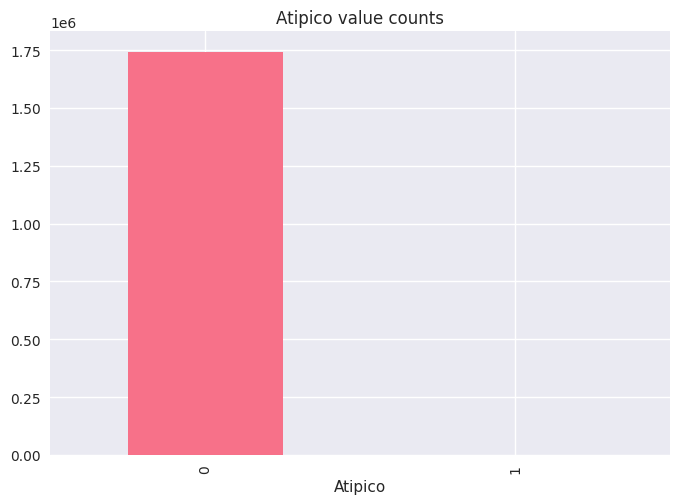

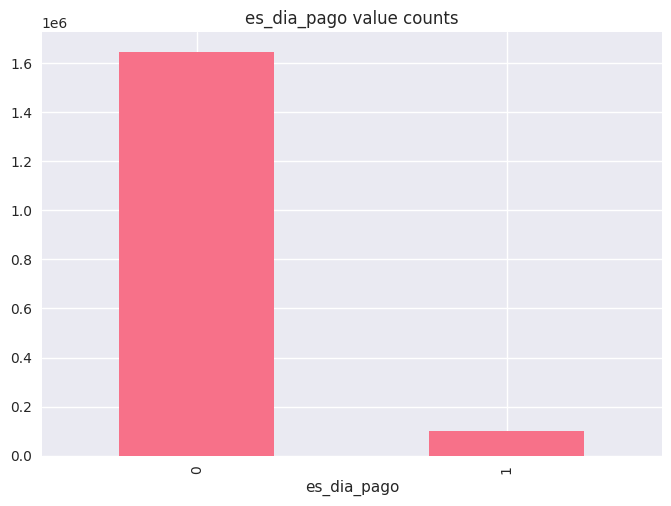

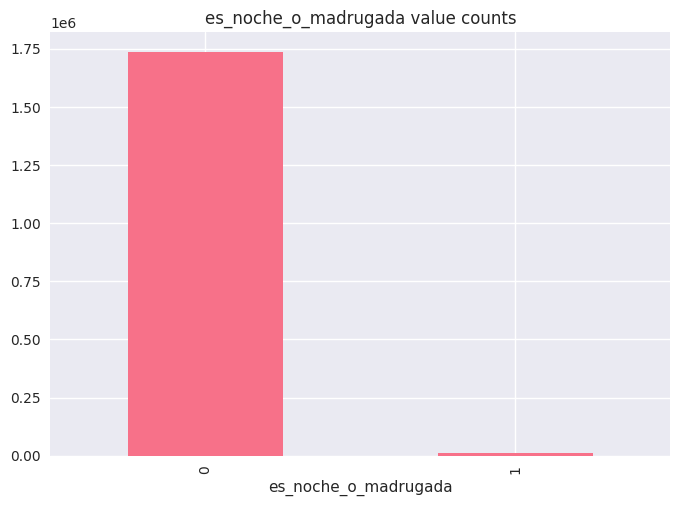

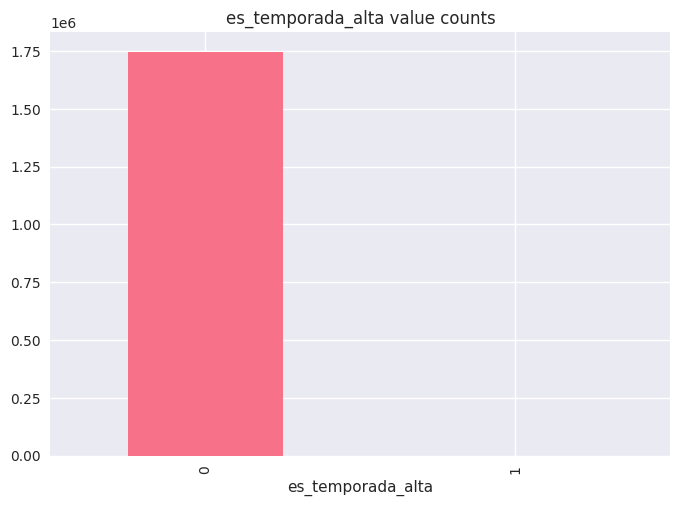

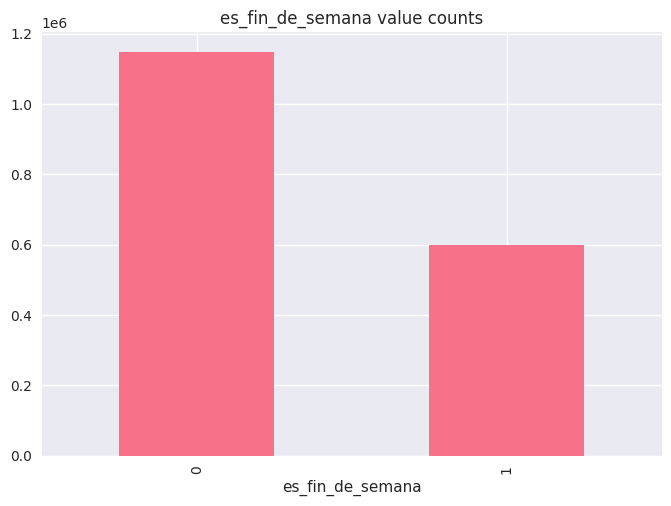

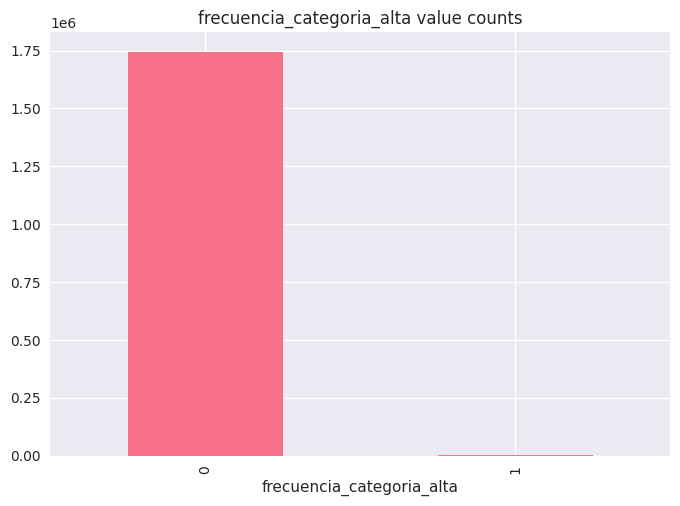

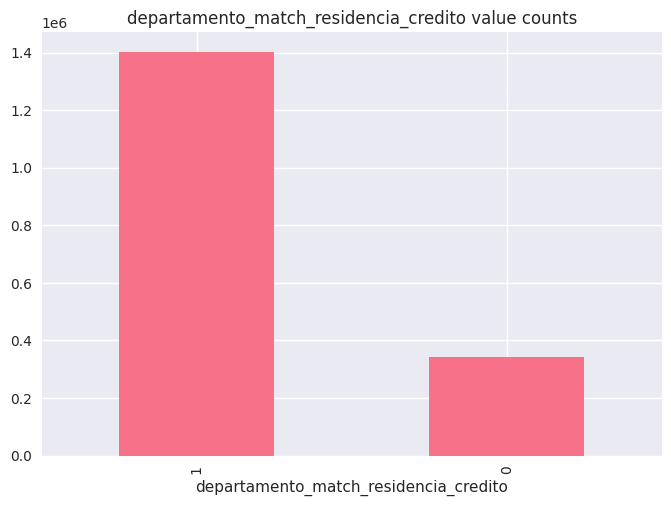

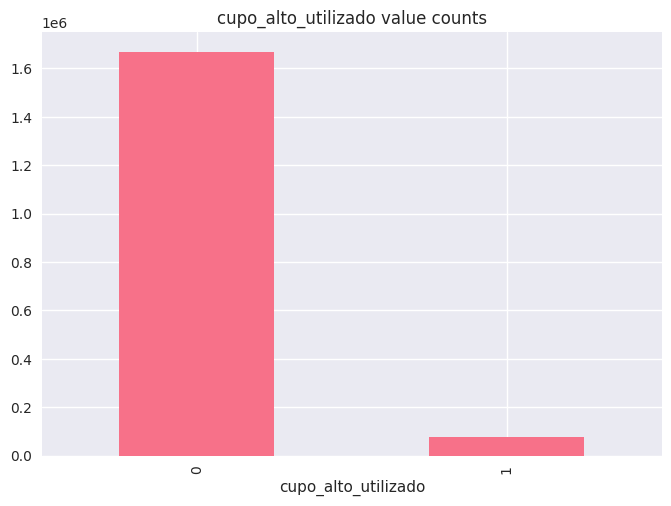

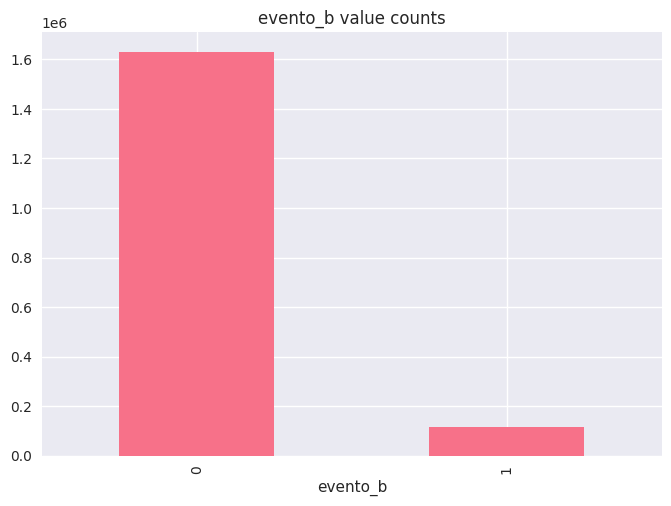

In [17]:
cat_cols = list(
    df_new_variables.select_dtypes(include=["object", "category", "bool"]).columns
)

for col in cat_cols:
    df_new_variables[col].value_counts().plot(kind="bar", title=f"{col} value counts")
    plt.show()


In [18]:
# Contar cuántos registros tienen Atipico == 1
cantidad_atipicos = (df_new_variables["Atipico"] == 1).sum()

print(f"🔍 Total de registros atípicos (Atipico == 1): {cantidad_atipicos}")


🔍 Total de registros atípicos (Atipico == 1): 403


**Análisis bivariable**

Es importante revisar la relación entre la variable target y las otras variables

**Target vs Variables Numericas**

📊 COMPARACIÓN DE VARIABLES NUMÉRICAS CON TARGET
Variables numéricas a analizar: 13
Target: Atipico


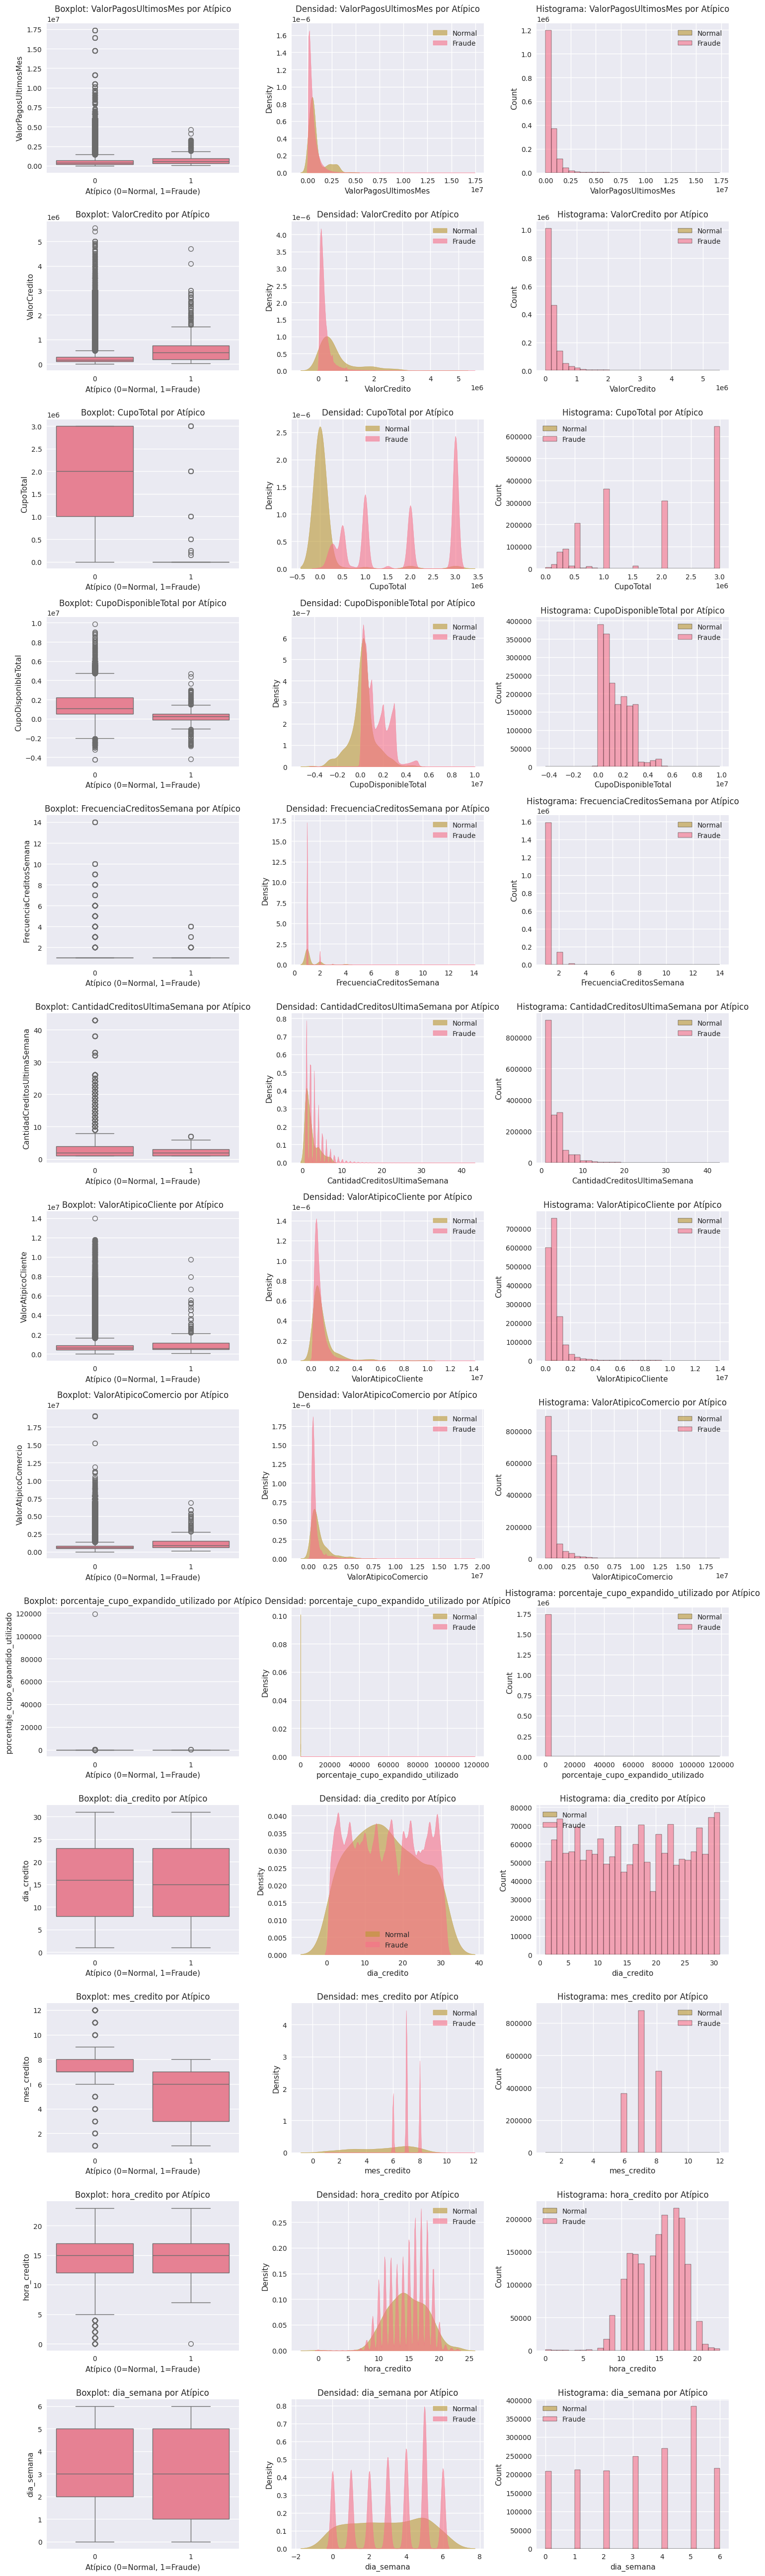


📈 ESTADÍSTICAS DESCRIPTIVAS POR GRUPO

🔍 VARIABLE: ValorPagosUltimosMes
----------------------------------------


,count,mean,std,min,25%,50%,75%,max
Atipico,,,,,,,,
0,1744264.0,531171.833310,539339.662532,194.0,184539.0,365333.0,690595.0,17374571.0
1,403.0,859227.724566,868565.343410,29638.0,320501.0,554109.0,935516.0,4614212.0



🔍 VARIABLE: ValorCredito
----------------------------------------


,count,mean,std,min,25%,50%,75%,max
Atipico,,,,,,,,
0,1744264.0,247511.458423,276434.848364,10000.0,100000.0,167700.0,282330.0,5542982.0
1,403.0,656552.106700,712584.728036,15304.0,178864.0,480000.0,745000.0,4697187.0



🔍 VARIABLE: CupoTotal
----------------------------------------


,count,mean,std,min,25%,50%,75%,max
Atipico,,,,,,,,
0,1744264.0,1.774785e+06,1.072049e+06,0.0,1000000.0,2000000.0,3000000.0,3000000.0
1,403.0,1.029777e+05,4.775727e+05,0.0,0.0,0.0,0.0,3000000.0


In [19]:
# ANÁLISIS BIVARIADO: VARIABLES NUMÉRICAS VS TARGET (ATIPICO)
print("📊 COMPARACIÓN DE VARIABLES NUMÉRICAS CON TARGET")
print("=" * 60)

# Obtener variables numéricas (excluyendo el target si es numérico)
num_cols = df_new_variables.select_dtypes(include=[np.number]).columns.tolist()
if "Atipico" in num_cols:
    num_cols.remove("Atipico")

print(f"Variables numéricas a analizar: {len(num_cols)}")
print(f"Target: Atipico")

if num_cols and "Atipico" in df_new_variables.columns:
    # Crear subplots
    n_cols = len(num_cols)
    fig, axes = plt.subplots(nrows=n_cols, ncols=3, figsize=(15, 4 * n_cols))

    # Manejar caso de una sola variable
    if n_cols == 1:
        axes = axes.reshape(1, -1)

    for i, col in enumerate(num_cols):
        # Limpiar datos para evitar errores
        df_clean = df_new_variables[[col, "Atipico"]].copy()
        df_clean[col] = df_clean[col].replace([np.inf, -np.inf], np.nan)
        df_clean = df_clean.dropna()

        if len(df_clean) == 0:
            # Sin datos válidos
            for j in range(3):
                axes[i, j].text(
                    0.5,
                    0.5,
                    f"Sin datos válidos\npara {col}",
                    ha="center",
                    va="center",
                    transform=axes[i, j].transAxes,
                )
                axes[i, j].set_title(f"Sin datos: {col} vs Atípico")
            continue

        # Boxplot: Variable numérica por categoría de Atípico
        sns.boxplot(x="Atipico", y=col, data=df_clean, ax=axes[i, 0])
        axes[i, 0].set_title(f"Boxplot: {col} por Atípico")
        axes[i, 0].set_xlabel("Atípico (0=Normal, 1=Fraude)")

        # Density plot: Distribución por categoría
        if df_clean[col].nunique() > 1:
            sns.kdeplot(
                data=df_clean,
                x=col,
                hue="Atipico",
                fill=True,
                common_norm=False,
                alpha=0.6,
                ax=axes[i, 1],
            )
            axes[i, 1].set_title(f"Densidad: {col} por Atípico")
            axes[i, 1].legend(labels=["Normal", "Fraude"])
        else:
            axes[i, 1].text(
                0.5,
                0.5,
                f"Sin variabilidad\nen {col}",
                ha="center",
                va="center",
                transform=axes[i, 1].transAxes,
            )
            axes[i, 1].set_title(f"Densidad: {col}")

        # Histogram: Distribución superpuesta
        sns.histplot(
            data=df_clean,
            x=col,
            hue="Atipico",
            bins=30,
            kde=False,
            alpha=0.6,
            ax=axes[i, 2],
        )
        axes[i, 2].set_title(f"Histograma: {col} por Atípico")
        axes[i, 2].legend(labels=["Normal", "Fraude"])

    plt.tight_layout()
    plt.show()

    # Estadísticas por grupo
    print(f"\n📈 ESTADÍSTICAS DESCRIPTIVAS POR GRUPO")
    print("=" * 60)

    for col in num_cols[:3]:  # Mostrar solo las primeras 3 para no saturar
        print(f"\n🔍 VARIABLE: {col}")
        print("-" * 40)

        df_clean = df_new_variables[[col, "Atipico"]].copy()
        df_clean[col] = df_clean[col].replace([np.inf, -np.inf], np.nan)
        df_clean = df_clean.dropna()

        if len(df_clean) > 0:
            stats_by_group = df_clean.groupby("Atipico")[col].describe()
            display(stats_by_group)
        else:
            print("Sin datos válidos para análisis")

else:
    print("❌ No se encontraron variables numéricas o target 'Atipico' para analizar")

**Traget VS variables categoricas**

📊 GRÁFICOS DE BARRAS - VARIABLES CATEGÓRICAS vs ATÍPICO
Variables categóricas: 16
Variables: ['DepartamentoResidencia', 'DepartamentoMayorFrecuenciaCompra', 'RiesgoAlmacen', 'DepartamentoCredito', 'EventoA', 'StatusComercioCredito', 'TipoAlmacenCredito', 'TipoCliente', 'es_dia_pago', 'es_noche_o_madrugada', 'es_temporada_alta', 'es_fin_de_semana', 'frecuencia_categoria_alta', 'departamento_match_residencia_credito', 'cupo_alto_utilizado', 'evento_b']


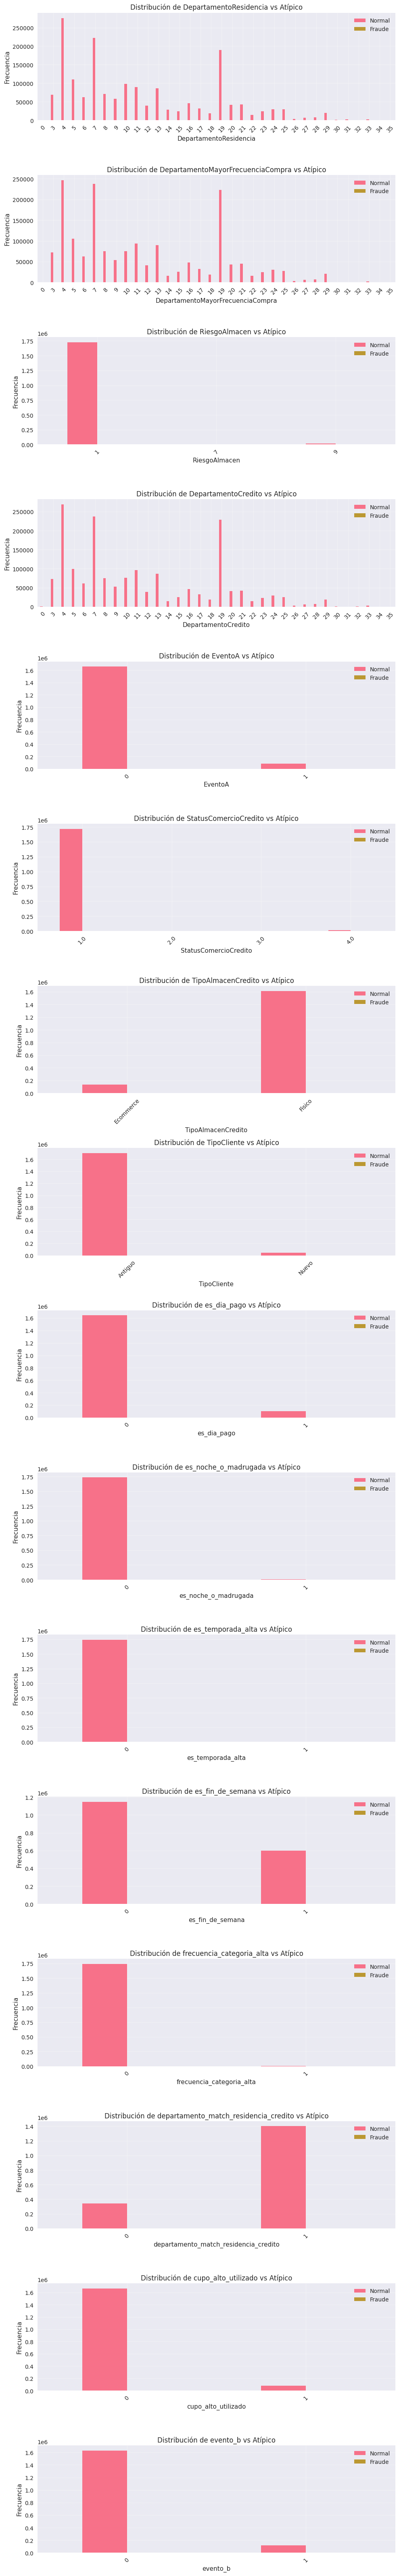

In [20]:
# GRÁFICOS DE BARRAS: VARIABLES CATEGÓRICAS VS TARGET
print("📊 GRÁFICOS DE BARRAS - VARIABLES CATEGÓRICAS vs ATÍPICO")
print("=" * 55)

# Obtener variables categóricas (excluyendo el target)
cat_vars = df_new_variables.select_dtypes(include=["category"]).columns.tolist()
if "Atipico" in cat_vars:
    cat_vars.remove("Atipico")

print(f"Variables categóricas: {len(cat_vars)}")
print(f"Variables: {cat_vars}")

# Crear gráficos de barras
n_vars = len(cat_vars)
if n_vars > 0:
    fig, axes = plt.subplots(nrows=n_vars, ncols=1, figsize=(10, 4 * n_vars))

    # Manejar caso de una sola variable
    if n_vars == 1:
        axes = [axes]

    for i, var in enumerate(cat_vars):
        # Crear tabla de contingencia
        crosstab = pd.crosstab(
            df_new_variables[var], df_new_variables["Atipico"], margins=True
        )

        # Gráfico de barras agrupadas (sin totales)
        crosstab.iloc[:-1, :-1].plot(kind="bar", ax=axes[i], rot=45)
        axes[i].set_title(f"Distribución de {var} vs Atípico")
        axes[i].set_xlabel(var)
        axes[i].set_ylabel("Frecuencia")
        axes[i].legend(["Normal", "Fraude"])
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("❌ No se encontraron variables categóricas")

In [21]:
# CROSSTABS COLOREADOS: VARIABLES CATEGÓRICAS VS TARGET
print("📋 CROSSTABS COLOREADOS - VARIABLES CATEGÓRICAS vs ATÍPICO")
print("=" * 58)

# Obtener variables categóricas (excluyendo el target)
cat_vars = df_new_variables.select_dtypes(include=["category"]).columns.tolist()
if "Atipico" in cat_vars:
    cat_vars.remove("Atipico")

print(f"Variables categóricas: {len(cat_vars)}")

# Crear crosstabs coloreados
for var in cat_vars:
    print(f"\n🔍 CROSSTAB: {var} vs Atípico")
    print("-" * 40)

    # Crear tabla de contingencia
    crosstab = pd.crosstab(
        df_new_variables[var], df_new_variables["Atipico"], margins=True
    )

    # Mostrar tabla coloreada (sin la fila/columna de totales para el color)
    crosstab_colored = crosstab.iloc[:-1, :-1].style.background_gradient(cmap="Blues")
    display(crosstab_colored)

    # Mostrar tabla completa sin color para ver totales
    print("Tabla con totales:")
    display(crosstab)

📋 CROSSTABS COLOREADOS - VARIABLES CATEGÓRICAS vs ATÍPICO
Variables categóricas: 16

🔍 CROSSTAB: DepartamentoResidencia vs Atípico
----------------------------------------


Atipico,0,1
DepartamentoResidencia,,
0,299,3
3,69123,14
4,276219,125
5,109972,18
6,62298,4
7,221921,31
8,71161,1
9,57916,10
10,97665,14


Tabla con totales:


Atipico,0,1,All
DepartamentoResidencia,,,
0,299,3,302
3,69123,14,69137
4,276219,125,276344
5,109972,18,109990
6,62298,4,62302
7,221921,31,221952
8,71161,1,71162
9,57916,10,57926
10,97665,14,97679



🔍 CROSSTAB: DepartamentoMayorFrecuenciaCompra vs Atípico
----------------------------------------


...

Atipico,0,1,All
cupo_alto_utilizado,,,
0,1666601,15,1666616
1,77663,388,78051
All,1744264,403,1744667



🔍 CROSSTAB: evento_b vs Atípico
----------------------------------------


Atipico,0,1
evento_b,,
0,1628483,319
1,115781,84


Tabla con totales:


Atipico,0,1,All
evento_b,,,
0,1628483,319,1628802
1,115781,84,115865
All,1744264,403,1744667


📊 **Análisis Multivariable**

En esta sección exploraremos las interacciones entre múltiples variables para identificar patrones complejos que pueden ser indicativos de fraude. Nos enfocaremos en:

1. **Análisis de correlaciones** entre variables numéricas
2. **Interacciones temporales** (día, hora, fin de semana) vs comportamiento financiero
3. **Patrones geográficos** combinando departamentos y montos
4. **Segmentación de clientes** por comportamiento de crédito
5. **Combinaciones de variables binarias** para identificar perfiles de riesgo

🔗 MATRIZ DE CORRELACIONES - VARIABLES NUMÉRICAS
Variables numéricas: 13


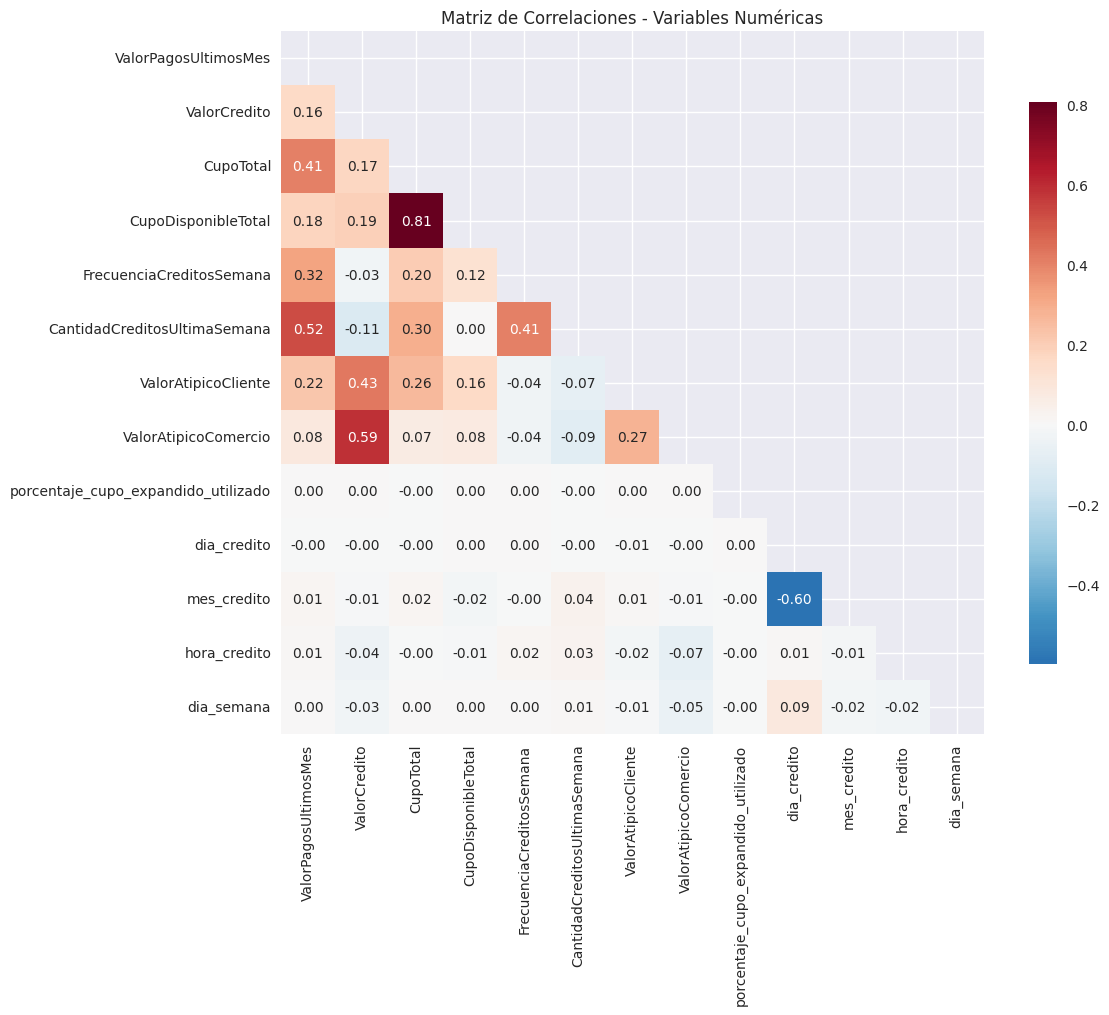


🔍 CORRELACIONES ALTAS (|r| > 0.7)
----------------------------------------


,Variable_1,Variable_2,Correlacion
0,CupoTotal,CupoDisponibleTotal,0.806972


In [22]:
# 1. MATRIZ DE CORRELACIONES - VARIABLES NUMÉRICAS
print("🔗 MATRIZ DE CORRELACIONES - VARIABLES NUMÉRICAS")
print("=" * 50)

# Obtener variables numéricas
num_vars = df_new_variables.select_dtypes(include=[np.number]).columns.tolist()
print(f"Variables numéricas: {len(num_vars)}")

if len(num_vars) > 1:
    # Calcular matriz de correlaciones
    correlation_matrix = df_new_variables[num_vars].corr()

    # Crear heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(
        correlation_matrix,
        mask=mask,
        annot=True,
        cmap="RdBu_r",
        center=0,
        square=True,
        fmt=".2f",
        cbar_kws={"shrink": 0.8},
    )
    plt.title("Matriz de Correlaciones - Variables Numéricas")
    plt.tight_layout()
    plt.show()

    # Identificar correlaciones altas (>0.7 o <-0.7)
    print(f"\n🔍 CORRELACIONES ALTAS (|r| > 0.7)")
    print("-" * 40)

    high_corr = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i + 1, len(correlation_matrix.columns)):
            corr_value = correlation_matrix.iloc[i, j]
            if abs(corr_value) > 0.7:
                var1 = correlation_matrix.columns[i]
                var2 = correlation_matrix.columns[j]
                high_corr.append(
                    {"Variable_1": var1, "Variable_2": var2, "Correlacion": corr_value}
                )

    if high_corr:
        high_corr_df = pd.DataFrame(high_corr).sort_values(
            "Correlacion", key=abs, ascending=False
        )
        display(high_corr_df)
    else:
        print("No se encontraron correlaciones altas entre variables")

else:
    print("❌ No hay suficientes variables numéricas para análisis de correlación")

🔎 1. Heatmap de correlación filtrado solo para clase Atípica

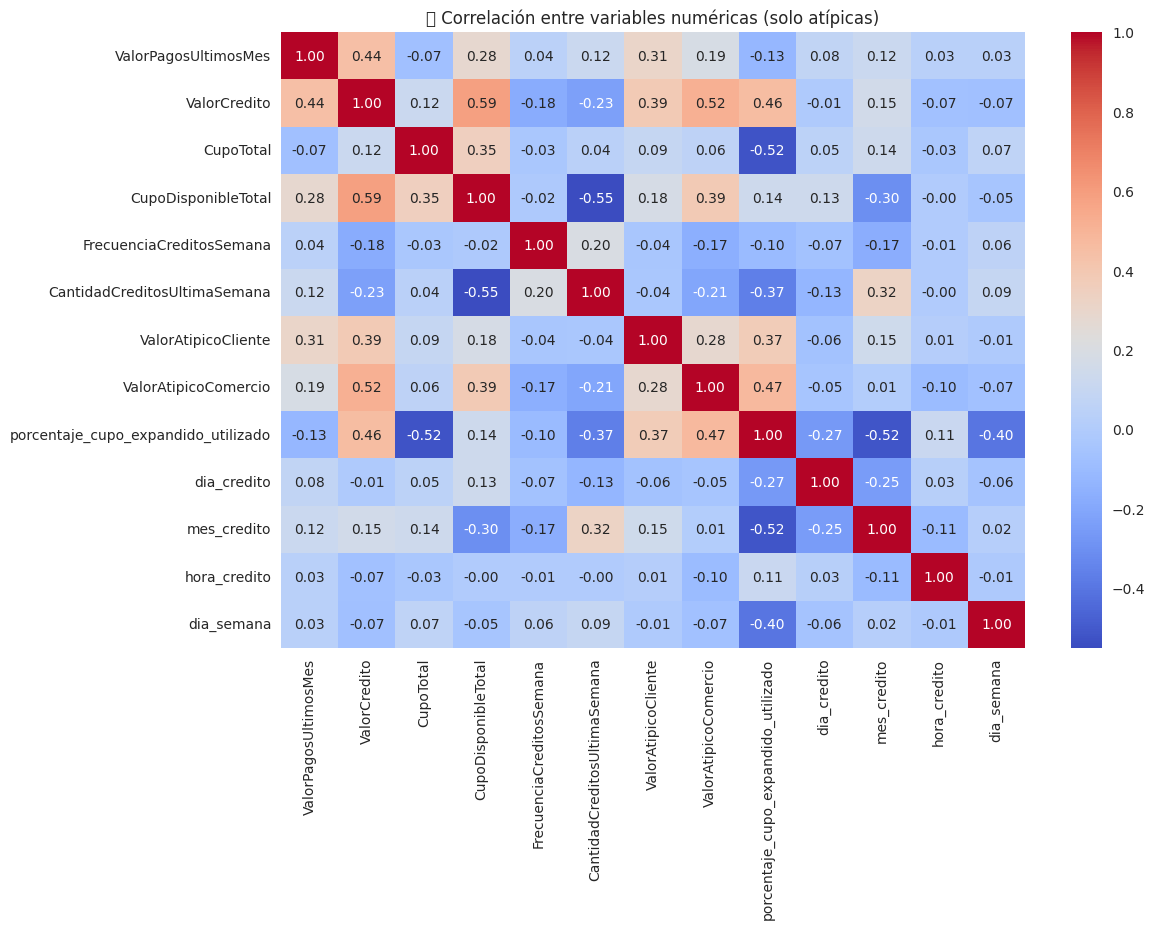

In [23]:
# Correlación entre numéricas dentro de las transacciones atípicas
fraudes = df_new_variables[df_new_variables["Atipico"] == 1]
corr_fraude = fraudes.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_fraude, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("🔍 Correlación entre variables numéricas (solo atípicas)")
plt.show()


🔄 2. Interacción cruzada: tipo de cliente × tipo de comercio

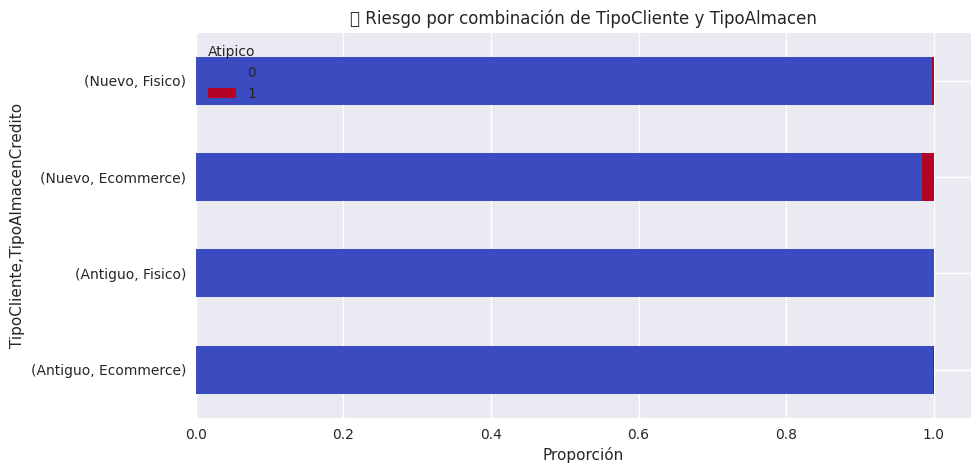

In [24]:
pd.crosstab(
    [df_new_variables["TipoCliente"], df_new_variables["TipoAlmacenCredito"]],
    df_new_variables["Atipico"],
    normalize="index",
).plot(kind="barh", stacked=True, figsize=(10, 5), colormap="coolwarm")
plt.title("🎯 Riesgo por combinación de TipoCliente y TipoAlmacen")
plt.xlabel("Proporción")
plt.show()


📊 3. Análisis cruzado: Departamento de residencia ≠ Departamento del crédito

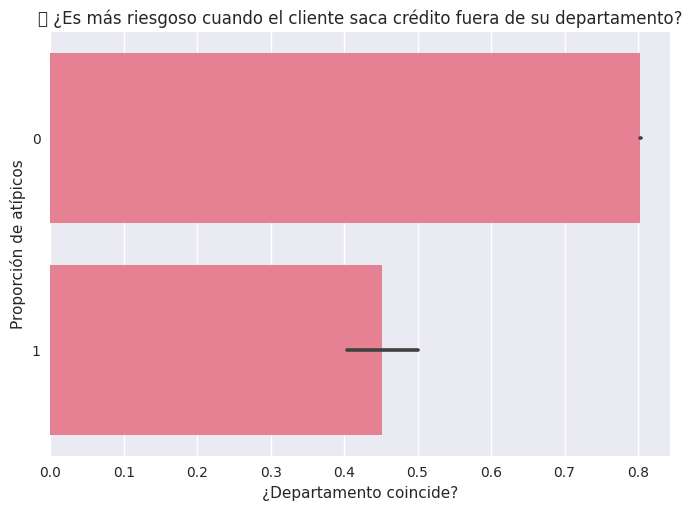

In [ ]:
sns.barplot(
    x="departamento_match", y="Atipico", data=df_new_variables, estimator=np.mean
)
plt.title(
    "🏠 ¿Es más riesgoso cuando el cliente saca crédito fuera de su departamento?"
)
plt.ylabel("Proporción de atípicos")
plt.xlabel("¿Departamento coincide?")
plt.show()


⏰ 4. Hora del crédito × día de la semana

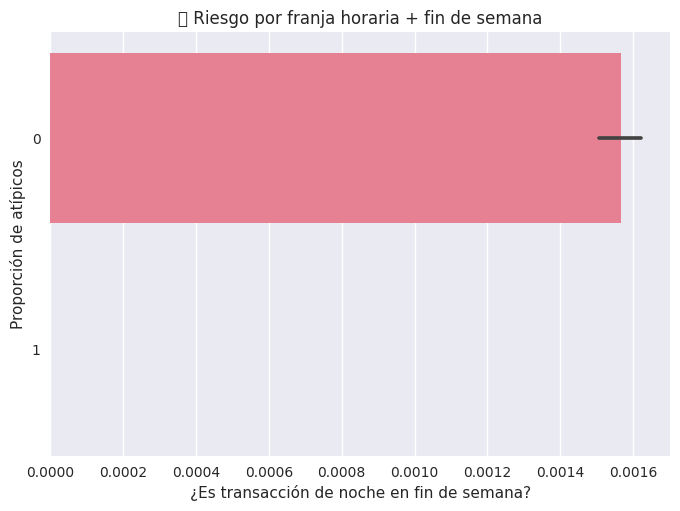

In [26]:
df_new_variables["dia_semana"] = pd.to_datetime(
    df_new_variables["FechaCredito"]
).dt.dayofweek
df_new_variables["hora"] = pd.to_datetime(df_new_variables["FechaCredito"]).dt.hour
df_new_variables["franja_riesgo"] = (
    (df_new_variables["hora"] < 6) | (df_new_variables["hora"] >= 22)
) & (df_new_variables["dia_semana"] >= 5)

sns.barplot(x="franja_riesgo", y="Atipico", data=df_new_variables, estimator=np.mean)
plt.title("⏱️ Riesgo por franja horaria + fin de semana")
plt.xlabel("¿Es transacción de noche en fin de semana?")
plt.ylabel("Proporción de atípicos")
plt.show()


In [27]:
# Top 10 usuarios con más transacciones atípicas
top_10_usuarios_atipicos = (
    df_new_variables[df_new_variables["Atipico"] == 1]
    .groupby("PersonaID")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="CantidadTransaccionesAtipicas")
)

print("🔟 Top 10 usuarios con más transacciones atípicas:")
print(top_10_usuarios_atipicos)


🔟 Top 10 usuarios con más transacciones atípicas:
                          PersonaID  CantidadTransaccionesAtipicas
0  VkZaU2NtUXdNVVZTVkZKUFVWUXdPUT09                              7
1  VkZaU2NrNVZNVFpUVkVaUFdub3dPUT09                              6
2  Vkd4U1RtVkZOVVZYVkVaUVZWUXdPUT09                              6
3  VkZod2NtVlZNVFpTV0d4T1ZWUXdPUT09                              5
4  VkRCU2JtVlZOWEZaZWtKUFpIb3dPUT09                              5
5  VkZod1FrMUZNVFphZWs1T1ZWUXdPUT09                              4
6  VkRCU2FrNVZNVlZoZWtKUVVWUXdPUT09                              4
7  VkZaU2JrMUZOVlZVVkZKUFpIb3dPUT09                              4
8  Vkcxd1FtVkZOVFpVV0doUFpIb3dPUT09                              4
9  Vkd0U1JtVlZPVVZoZWs1T1pIb3dPUT09                              4


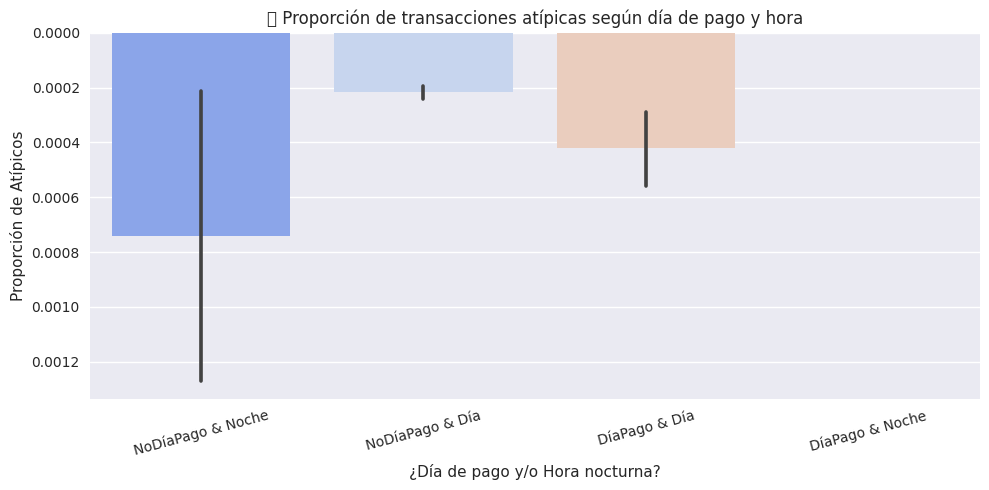

In [30]:
# Crear variable combinada a partir de columnas existentes
df_new_variables["dia_pago_y_noche"] = df_new_variables.apply(
    lambda row: f"{'DíaPago' if row['es_dia_pago'] == 1 else 'NoDíaPago'} & {'Noche' if row['es_noche_o_madrugada'] == 1 else 'Día'}",
    axis=1,
)

# Gráfico
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_new_variables,
    x="dia_pago_y_noche",
    y="Atipico",
    estimator=np.mean,
    palette="coolwarm",
)
plt.title("🌙 Proporción de transacciones atípicas según día de pago y hora")
plt.ylabel("Proporción de Atípicos")
plt.xlabel("¿Día de pago y/o Hora nocturna?")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
